In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [2]:
data = pd.read_csv("/content/adult.data")
print("Dataset loaded successfully")

Dataset loaded successfully


In [6]:
data.columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'educational-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

In [7]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [8]:
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [10]:
data.shape

(32560, 15)

In [12]:
X = data[["age", "hours-per-week"]]
print("Features selected for clustering")

Features selected for clustering


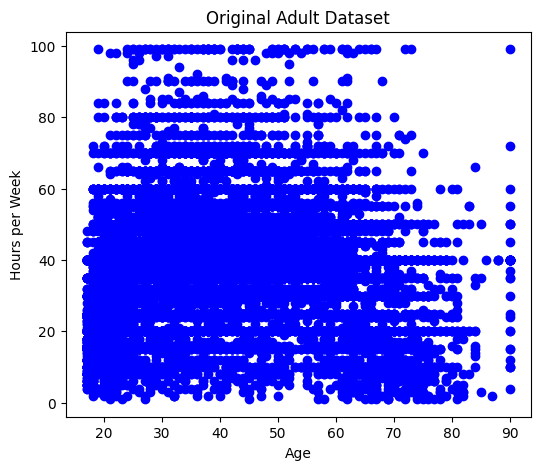

In [26]:
plt.figure(figsize=(6, 5))
plt.scatter(X["age"], X["hours-per-week"], color="blue")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Original Adult Dataset")
plt.show()

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete using StandardScaler")

Feature scaling complete using StandardScaler


In [16]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

print("Model trained successfully")

Model trained successfully


In [18]:
labels = kmeans.labels_
data['Cluster'] = labels

data[['age', 'hours-per-week', 'Cluster']].head()

,age,hours-per-week,Cluster
0,50,13,2
1,38,40,0
2,53,40,1
3,28,40,0
4,37,40,0


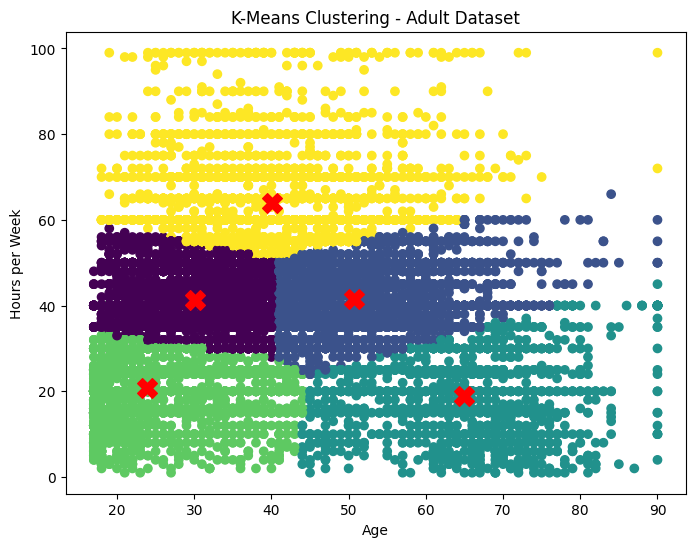

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['age'],
    X['hours-per-week'],
    c=labels,
    cmap='viridis'
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    marker='X'
)

plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("K-Means Clustering - Adult Dataset")
plt.show()

In [20]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

wcss = kmeans.inertia_
print("WCSS (Inertia):", wcss)

db_score = davies_bouldin_score(X_scaled, labels)
print("Davies-Bouldin Index:", db_score)

Silhouette Score: 0.44189661345383113
WCSS (Inertia): 16717.34491485116
Davies-Bouldin Index: 0.7337640389086182
